In [1]:
import pandas as pd

#charger dataset
df = pd.read_csv("../data/superstore.csv")

#Appercu
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
#structure dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [3]:
# Nettayage
# 4.1: Standardiser les noms de colonnes (Tres important pour SQL et Python)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales'],
      dtype='str')

In [4]:
# 4.2: Valeurs manquantes
df.isnull().sum()

row_id            0
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_id       0
customer_name     0
segment           0
country           0
city              0
state             0
postal_code      11
region            0
product_id        0
category          0
sub-category      0
product_name      0
sales             0
dtype: int64

In [5]:
#Supprimer les valeurs manquantes ici Postal Code
df = df.dropna(subset=['postal_code'])

In [6]:
# 4.3 Doublons (ici pas de doublons sinon on devais faire df = df.drop-duplicates())
df.duplicated().sum()

np.int64(0)

In [7]:
#4.4  Conversion des donnees en format de date et time
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [8]:
#4.5 Feature engineering (tres important)
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()

In [9]:
# 4.6 verifiction 
df.describe()

,row_id,order_date,postal_code,sales,year,month
count,9789.000000,3955,9789.000000,9789.000000,3955.000000,3955.000000
mean,4896.705588,2017-03-14 18:03:54.841972,55273.322403,230.116193,2016.728445,6.452845
min,1.000000,2015-01-02 00:00:00,1040.000000,0.444000,2015.000000,1.000000
25%,2449.000000,2016-04-05 00:00:00,23223.000000,17.248000,2016.000000,3.000000
50%,4896.000000,2017-05-02 00:00:00,58103.000000,54.384000,2017.000000,6.000000
75%,7344.000000,2018-03-07 00:00:00,90008.000000,210.392000,2018.000000,9.000000
max,9800.000000,2018-12-11 00:00:00,99301.000000,22638.480000,2018.000000,12.000000
std,2827.486899,NaN,32041.223413,625.302079,1.119373,3.499547


In [10]:
# 5. Sauvegarde des donnees propres (super important pour Power BI et SQL)
df.to_csv("../data/cleaned_superstore.csv", index=False)

# ===========================
# KEY PERFORMANCE INDICATORS
# ===========================

In [11]:
print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'year', 'month', 'month_name'],
      dtype='str')


In [12]:
import numpy as np

# Générer un profit entre -20% et +30% des ventes
df['profit'] = df['sales'] * np.random.uniform(-0.2, 0.3, size=len(df))
print(df.profit)

0       -36.082421
1       -19.942719
2        -1.610680
3      -160.103132
4        -3.123459
           ...    
9795     -0.049245
9796     -1.040184
9797      0.379561
9798      5.354991
9799     -1.189589
Name: profit, Length: 9789, dtype: float64


In [13]:
df.to_csv("../data/cleaned_superstore.csv", index=False)

In [14]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 2252607.4127
Total Profit: 119924.93860731815
Total Orders: 4916


#  Insight: 
# The company genreated X revenue with Y profit across Z orders.
# indication a heathy business performance.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

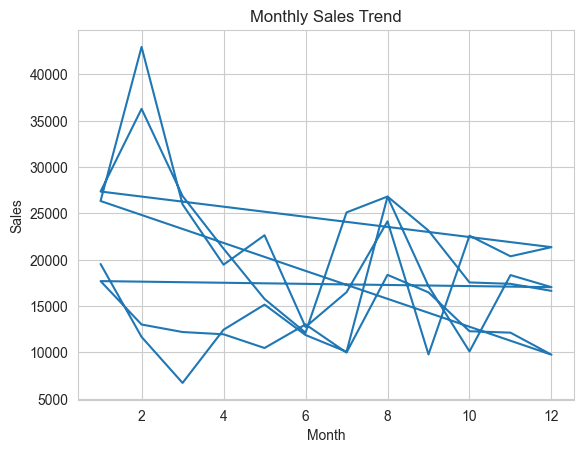

In [16]:
# Sales over time
monthly_sales = df.groupby(['year', 'month']) ['sales'].sum().reset_index()

plt.figure()
plt.plot(monthly_sales['month'], monthly_sales['sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# Insight:
# Sales show seasonal trends with peaks during specific months

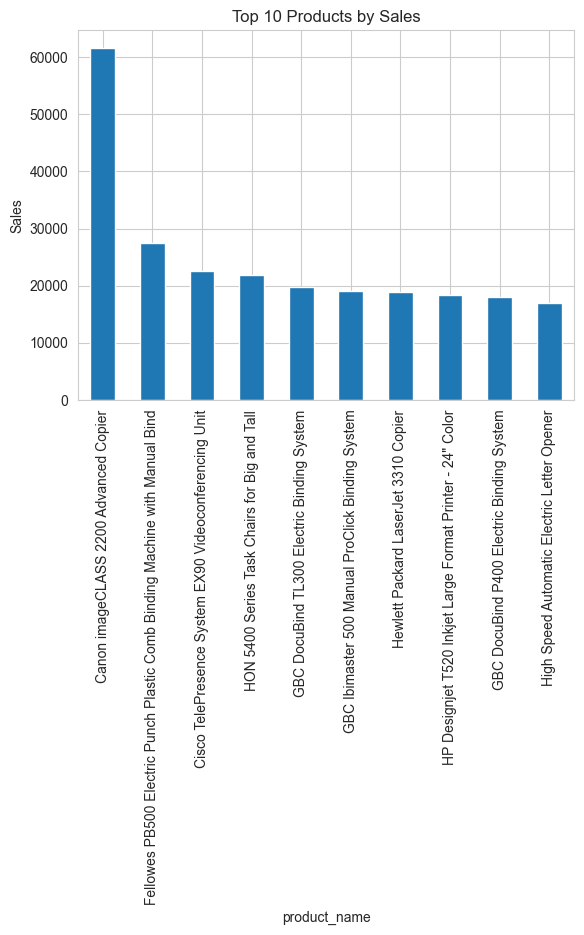

In [17]:
top_products = df.groupby('product_name') ['sales'].sum().sort_values(ascending=False).head(10)
plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")
plt.show()

# Insight: 
# A few products dominate total revenue, indicating a strong concentration

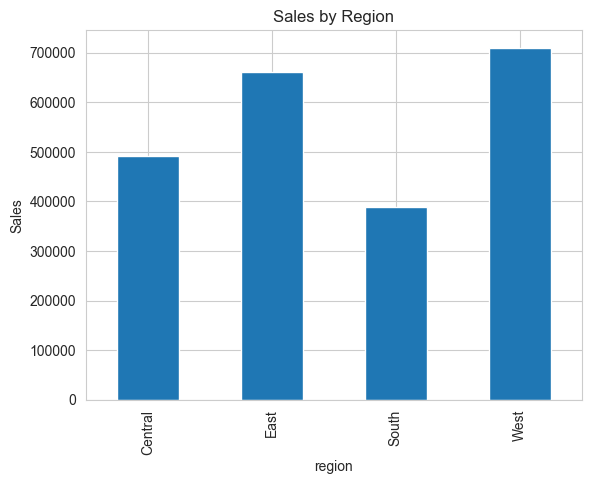

In [18]:
region_sales = df.groupby(['region']) ['sales'].sum()

plt.figure()
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

# Insight:
# Some regions outperform others significantly in total sales.

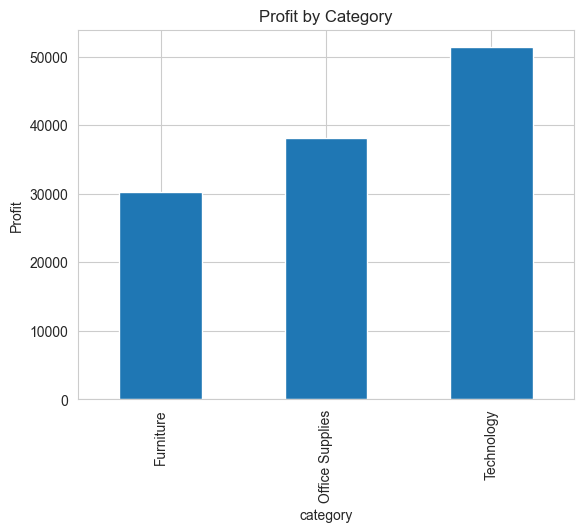

In [19]:
category_profit = df.groupby('category') ['profit'].sum()

plt.figure()
category_profit.plot(kind = 'bar')
plt.title("Profit by Category") 
plt.ylabel("Profit")
plt.show()


# Insight:
# Certain categories genrate significantly higher profit margins.

In [20]:
loss_products = df[df['profit'] < 0]

loss_products.groupby('product_name') ['profit'].sum().sort_values().head(10)

product_name
HON 5400 Series Task Chairs for Big and Tall                                  -1445.879796
Canon imageCLASS 2200 Advanced Copier                                         -1413.930541
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                      -1232.085953
3D Systems Cube Printer, 2nd Generation, Magenta                              -1037.539094
Martin Yale Chadless Opener Electric Letter Opener                             -997.246636
Hon 94000 Series Round Tables                                                  -974.149927
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    -920.611342
GBC DocuBind P400 Electric Binding System                                      -852.941844
Hewlett Packard LaserJet 3310 Copier                                           -817.507232
Cubify CubeX 3D Printer Double Head Print                                      -806.334636
Name: profit, dtype: float64

# Insight
# Some products consistently generate losses and should be reviewed.

In [21]:
# connection de SQLite avec Python
import sqlite3

conn = sqlite3.connect("sales.db") 
df.to_sql("sales", conn, if_exists="replace", index=False)

9789

# ==================
# SQL ANALYSIS
# ===================

In [22]:
# Total sales
query = "SELECT SUM(sales) AS total_sales FROM sales;"
pd.read_sql(query, conn)

,total_sales
0,2.252607e+06


In [23]:
# Total profit
query = "SELECT SUM(profit) AS total_profit FROM sales;"
pd.read_sql(query, conn)


,total_profit
0,119924.938607


In [24]:
# Top products
query = """
    SELECT product_name, SUM(sales) AS total_sales 
    FROM  sales 
    GROUP BY product_name 
    ORDER BY total_sales DESC
    LIMIT 10;
"""
pd.read_sql(query, conn)

,product_name,total_sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


In [25]:
# Sales by region
query = """
    SELECT region, SUM(sales) AS total_sales
    FROM sales
    GROUP BY region 
    ORDER BY total_sales DESC;"""
pd.read_sql(query, conn)



,region,total_sales
0,West,710219.6845
1,East,660589.3560
2,Central,492646.9132
3,South,389151.4590


In [32]:
# Sales by month
query = """ SELECT month, SUM(sales) AS total_sales
    FROM sales
    GROUP BY month
    ORDER BY month DESC;"""
pd.read_sql(query, conn)

,month,total_sales
0,NaN,1.386864e+06
1,2.0,1.039512e+05
2,8.0,9.615545e+04
3,1.0,9.095798e+04
4,3.0,7.178869e+04
5,11.0,6.827431e+04
6,9.0,6.658237e+04
7,4.0,6.509495e+04
8,12.0,6.481937e+04
9,5.0,6.407205e+04
